In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [8]:

# Load raw dataset
file_path = "SMSSpamCollection"   

df = pd.read_csv(file_path, sep="\t", header=None, names=["label", "message"])

# Convert labels to binary
df["label"] = df["label"].map({"ham": 0, "spam": 1})

# Save raw data
df.to_csv("raw_data.csv", index=False)

print("Raw data shape:", df.shape)
df.head()

Raw data shape: (5572, 2)


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# First split: Train vs Temp (val + test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=123,
    stratify=df["label"]
)

# Second split: Validation vs Test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=123,
    stratify=temp_df["label"]
)

# Save splits
train_df.to_csv("train.csv", index=False)
val_df.to_csv("validation.csv", index=False)
test_df.to_csv("test.csv", index=False)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (3900, 2)
Validation shape: (836, 2)
Test shape: (836, 2)


### Printing and plotting the target variable distribution


Target Distribution (seed = 42)

train.csv
Total: 3900
Ham (0): 3377
Spam (1): 523
Spam ratio: 0.134

validation.csv
Total: 836
Ham (0): 724
Spam (1): 112
Spam ratio: 0.134

test.csv
Total: 836
Ham (0): 724
Spam (1): 112
Spam ratio: 0.134


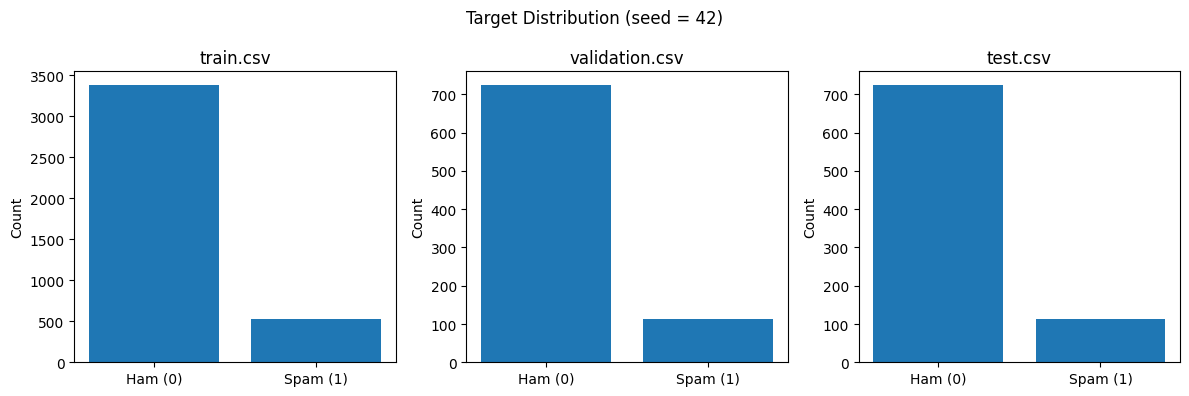

In [ ]:
version = "seed = 42"   

import pandas as pd
import matplotlib.pyplot as plt

files = ["train.csv", "validation.csv", "test.csv"]

print(f"\nTarget Distribution ({version})")
print("="*50)

plt.figure(figsize=(12, 4))

for i, file in enumerate(files, 1):
    df = pd.read_csv(file)
    counts = df["label"].value_counts().sort_index()
    
    num_0 = counts.get(0, 0)
    num_1 = counts.get(1, 0)
    total = len(df)
    
    # ---- PRINT ----
    print(f"\n{file}")
    print(f"Total: {total}")
    print(f"Ham (0): {num_0}")
    print(f"Spam (1): {num_1}")
    print(f"Spam ratio: {num_1/total:.3f}")
    
    # ---- PLOT ----
    plt.subplot(1, 3, i)
    plt.bar(["Ham (0)", "Spam (1)"], [num_0, num_1])
    plt.title(file)
    plt.ylabel("Count")

plt.suptitle(f"Target Distribution ({version})")
plt.tight_layout()
plt.show()



Target Distribution (seed = 123)

train.csv
Total: 3900
Ham (0): 3377
Spam (1): 523
Spam ratio: 0.134

validation.csv
Total: 836
Ham (0): 724
Spam (1): 112
Spam ratio: 0.134

test.csv
Total: 836
Ham (0): 724
Spam (1): 112
Spam ratio: 0.134


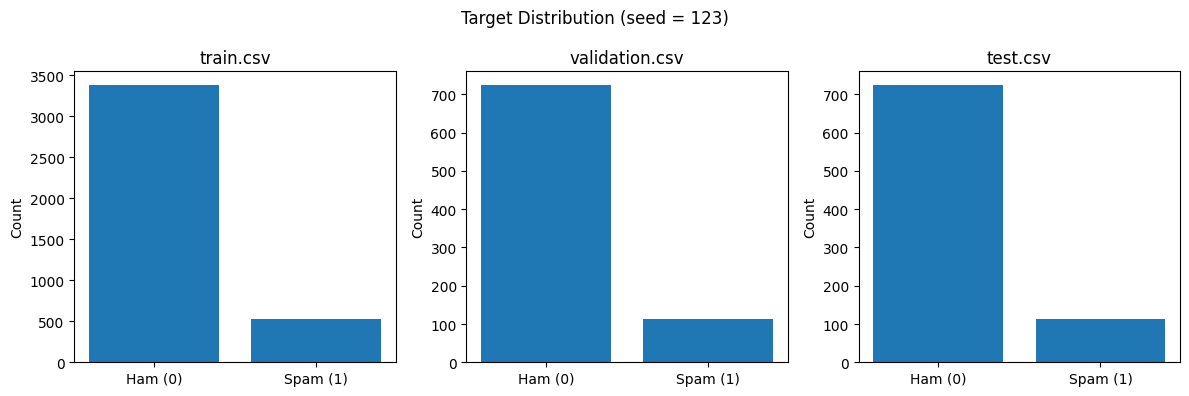

In [14]:
version = "seed = 123"   

import pandas as pd
import matplotlib.pyplot as plt

files = ["train.csv", "validation.csv", "test.csv"]

print(f"\nTarget Distribution ({version})")
print("="*50)

plt.figure(figsize=(12, 4))

for i, file in enumerate(files, 1):
    df = pd.read_csv(file)
    counts = df["label"].value_counts().sort_index()
    
    num_0 = counts.get(0, 0)
    num_1 = counts.get(1, 0)
    total = len(df)
    
    # ---- PRINT ----
    print(f"\n{file}")
    print(f"Total: {total}")
    print(f"Ham (0): {num_0}")
    print(f"Spam (1): {num_1}")
    print(f"Spam ratio: {num_1/total:.3f}")
    
    # ---- PLOT ----
    plt.subplot(1, 3, i)
    plt.bar(["Ham (0)", "Spam (1)"], [num_0, num_1])
    plt.title(file)
    plt.ylabel("Count")

plt.suptitle(f"Target Distribution ({version})")
plt.tight_layout()
plt.show()


Note:
The class distribution remains identical across versions because stratified sampling was used.
However, the actual data instances in each split differ due to different random seeds.
DVC successfully tracks these different data versions.